In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# برای نمایش نمودارها به صورت درونی در Jupyter
%matplotlib inline

In [2]:
# آدرس فایل اکسل نسبت به پوشه notebooks
# دقت کنید که نام فایل دقیقاً باید مطابق با نام فایل اصلی شما باشد
file_path = "../data/LAMP 14050615 33M 2.xlsx"

# نام شیت شما طولانی است، پس آن را به صورت دقیق وارد می‌کنیم
sheet_name = "filtered_data"

# خواندن فایل اکسل
df = pd.read_excel(file_path, sheet_name=sheet_name)

# نمایش ۵ سطر اول برای اطمینان از درست خوانده شدن داده‌ها
display(df.head())

,time,ADC_READ[1]
0,3600.596,2289
1,3601.596,2293
2,3602.595,2279
3,3603.595,2278
4,3604.595,2280


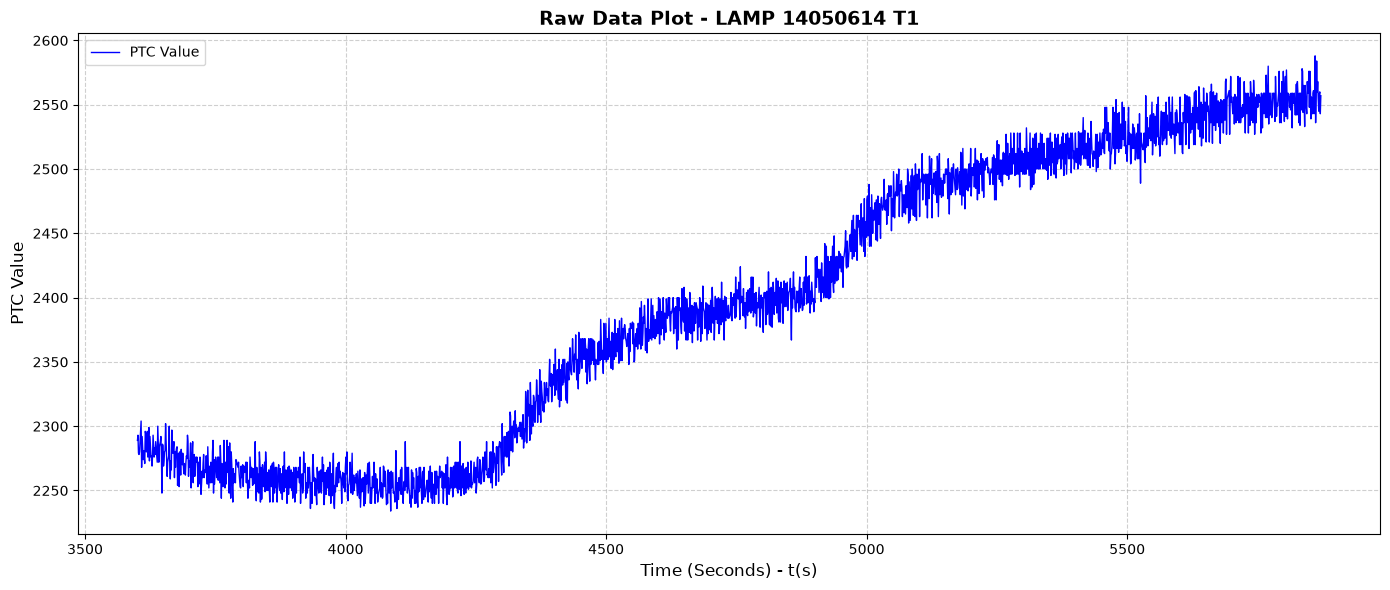

In [3]:
# تنظیمات ابعاد نمودار
plt.figure(figsize=(14, 6))

# رسم نمودار: محور X زمان به ثانیه (t(s)) و محور Y مقادیر PTC
plt.plot(df['time'], df['ADC_READ[1]'], color='blue', linewidth=1, label='PTC Value')

# تنظیمات عنوان و برچسب‌های محورها
plt.title('Raw Data Plot - LAMP 14050614 T1', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds) - t(s)', fontsize=12)
plt.ylabel('PTC Value', fontsize=12)

# نمایش راهنما (Legend) و شبکه‌بندی (Grid)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# نرم‌سازی محورها برای نمایش بهتر
plt.tight_layout()

# ذخیره نمودار در پوشه figures (اختیاری)
# plt.savefig("../figures/raw_data_plot.png", dpi=300)

# نمایش نمودار
plt.show()

In [4]:
import pandas as pd
import numpy as np

# 1. یافتن زمان شروع و پایان داده‌ها
min_time = df['time'].min()
max_time = df['time'].max()
print(max_time)

# 2. محاسبه زمان‌های هدف (هر 600 ثانیه یک‌بار)
# شروع را روی ближайний مضرب 600 تنظیم می‌کنیم (مثلاً اگر داده‌ها از 210 شروع شده باشند، اولین زمان هدف 600 خواهد بود)
start_time = int(min_time // 60) * 60
target_times = list(range(start_time, int(max_time) + 60, 60))

# 3. لیست خالی برای ذخیره نتایج
results = []

# 4. حلقه برای محاسبه میانگین هر بازه
for t_target in target_times:
    # تعریف پنجره زمانی: 0.5 ثانیه قبل تا 0.5 ثانیه بعد
    t_low = t_target - 10
    t_high = t_target + 10
    
    # فیلتر کردن داده‌ها در این پنجره زمانی 1 ثانیه‌ای
    window_df = df[(df['time'] >= t_low) & (df['time'] <= t_high)]
    
    # محاسبه میانگین ptc در صورت وجود داده در این بازه
    if not window_df.empty:
        mean_ptc = window_df['ADC_READ[1]'].mean()
        results.append({'Time (s)': t_target, 'Mean PTC': mean_ptc})

# 5. تبدیل نتایج به DataFrame
df_result = pd.DataFrame(results)

# نمایش نتایج در Jupyter
print("میانگین داده‌ها در بازه‌های 600 ثانیه‌ای:")
display(df_result)

# 6. ذخیره در فایل اکسل جدید
output_path = "../data/LAMP_14050614_M2_averages.xlsx"
df_result.to_excel(output_path, index=False)

print(f"\nفایل اکسل با موفقیت در مسیر زیر ذخیره شد:\n{output_path}")

5871.595
میانگین داده‌ها در بازه‌های 600 ثانیه‌ای:


,Time (s),Mean PTC
0,3600,2286.555556
1,3660,2278.611111
2,3720,2265.315789
3,3780,2263.850000
4,3840,2259.764706
5,3900,2257.722222
6,3960,2258.210526
7,4020,2254.687500
8,4080,2253.736842
9,4140,2253.400000



فایل اکسل با موفقیت در مسیر زیر ذخیره شد:
../data/LAMP_14050614_M2_averages.xlsx


In [5]:
# آدرس فایل اکسل نسبت به پوشه notebooks
# دقت کنید که نام فایل دقیقاً باید مطابق با نام فایل اصلی شما باشد
file_path = "../data/LAMP_14050614_M2_averages.xlsx"

# نام شیت شما طولانی است، پس آن را به صورت دقیق وارد می‌کنیم
sheet_name = "Sheet1"

# خواندن فایل اکسل
df = pd.read_excel(file_path, sheet_name=sheet_name)

# نمایش ۵ سطر اول برای اطمینان از درست خوانده شدن داده‌ها
display(df.head())

,Time (s),Mean PTC
0,3600,2286.555556
1,3660,2278.611111
2,3720,2265.315789
3,3780,2263.850000
4,3840,2259.764706


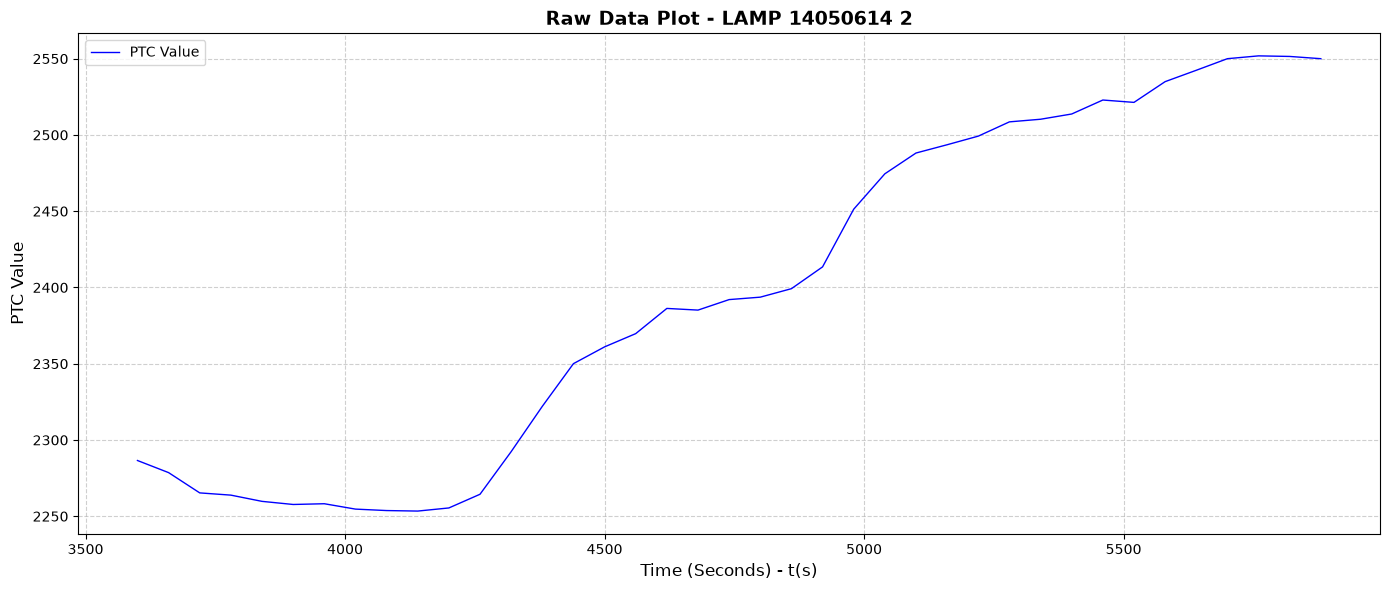

In [6]:
# تنظیمات ابعاد نمودار
plt.figure(figsize=(14, 6))

# رسم نمودار: محور X زمان به ثانیه (t(s)) و محور Y مقادیر PTC
plt.plot(df['Time (s)'], df['Mean PTC'], color='blue', linewidth=1, label='PTC Value')

# تنظیمات عنوان و برچسب‌های محورها
plt.title('Raw Data Plot - LAMP 14050614 2', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds) - t(s)', fontsize=12)
plt.ylabel('PTC Value', fontsize=12)

# نمایش راهنما (Legend) و شبکه‌بندی (Grid)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# نرم‌سازی محورها برای نمایش بهتر
plt.tight_layout()

# ذخیره نمودار در پوشه figures (اختیاری)
# plt.savefig("../figures/raw_data_plot.png", dpi=300)

# نمایش نمودار
plt.show()